In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set plotting style for clean visualizations
sns.set_theme(style="whitegrid")
%matplotlib inline

# Load our cleaned data from the processed folder
df = pd.read_csv("../data/processed/cleaned_algerian_fire_data.csv")

# Quick verification
print(f"Dataset loaded successfully. Shape: {df.shape}")
df.head()

Matplotlib is building the font cache; this may take a moment.


Dataset loaded successfully. Shape: (243, 15)


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


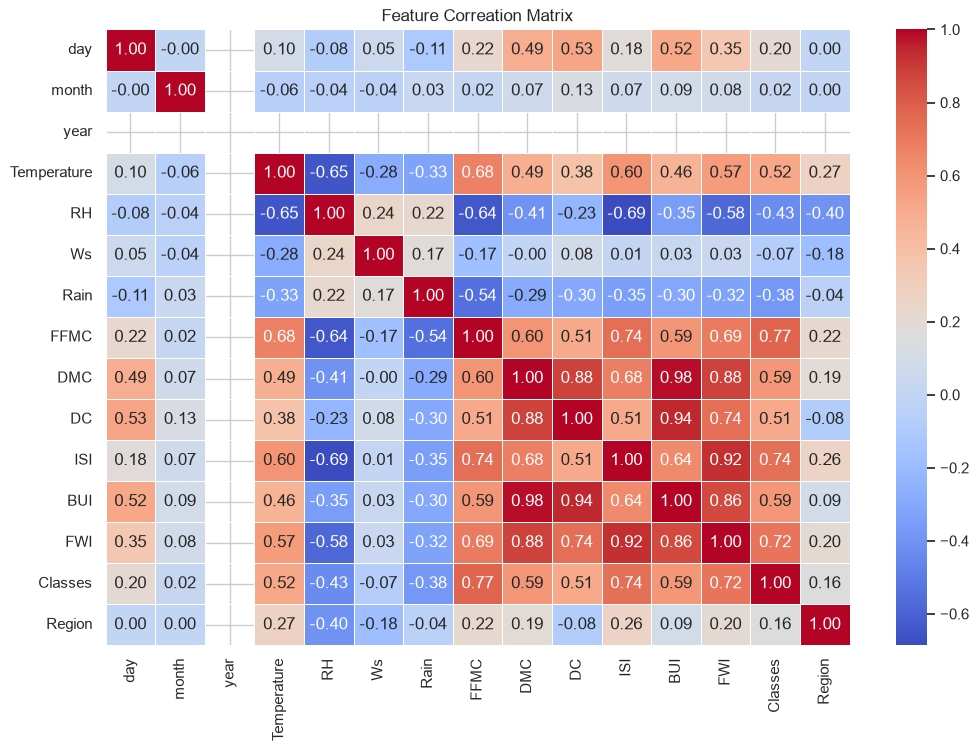

In [2]:
# Check Feature Correlations 

# Before plotting individual charts, let's see which features have the strongest relationship with fires. We do this using a Correlation Heatmap.
plt.figure(figsize=(12, 8))

# calculate correlation matrix for numerical columns
corr = df.corr()

# plot the heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correation Matrix")
plt.show()

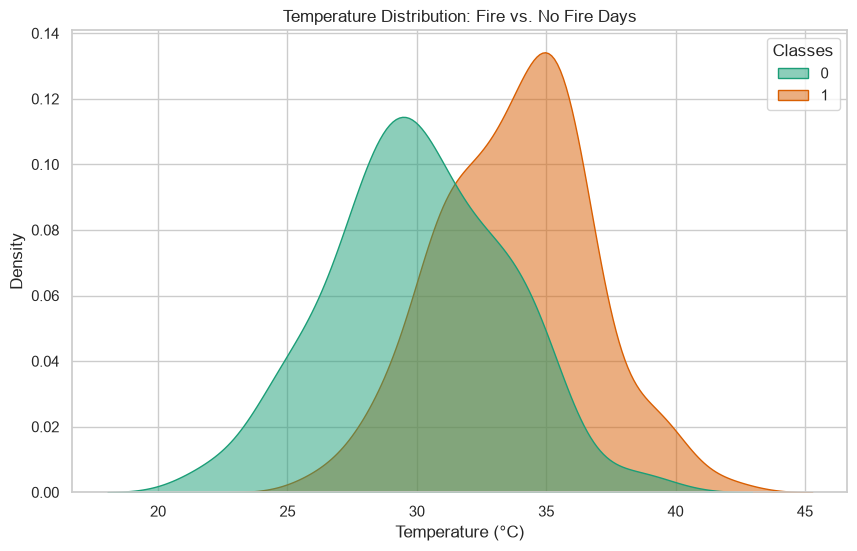

In [3]:
# Now that we know FFMC, Temperature, and RH are critical factors, let's look closer at their exact distributions.
# plot a Density/Distribution Chart to see the clear separation of Temperature across Fire vs. No Fire days:

plt.figure(figsize=(10, 6))
# plot distribution of Temperature split by Classes (0= No fire, 1 = Fire)
sns.kdeplot(data=df, x="Temperature", hue="Classes", fill=True, palette="Dark2", common_norm=False, alpha=0.5)

plt.title("Temperature Distribution: Fire vs. No Fire Days")
plt.xlabel("Temperature (°C)")
plt.ylabel("Density")
plt.show()

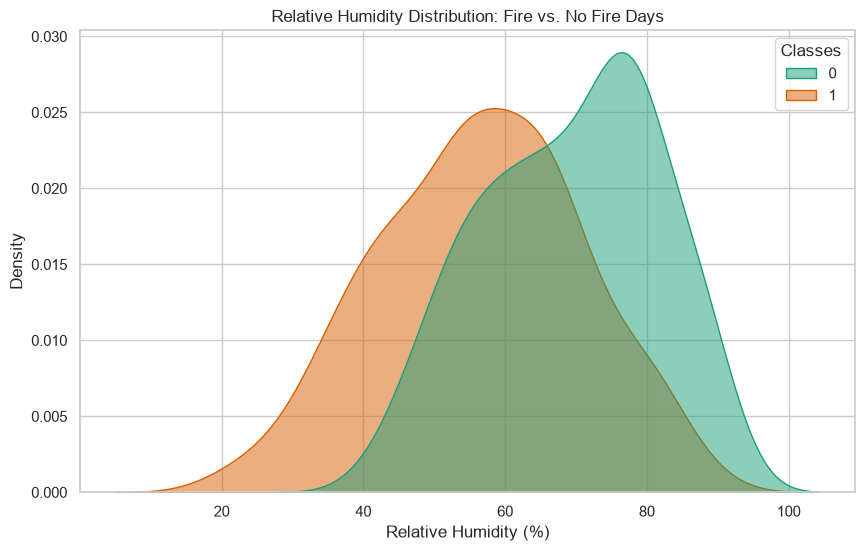

In [5]:
# Checking Relative Humidity (RH)
plt.figure(figsize=(10, 6))

# Plot distribution of Relative Humidity split by Classes
sns.kdeplot(data=df, x="RH", hue="Classes", fill=True, palette="Dark2", common_norm=False, alpha=0.5)

plt.title("Relative Humidity Distribution: Fire vs. No Fire Days")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Density")
plt.show()

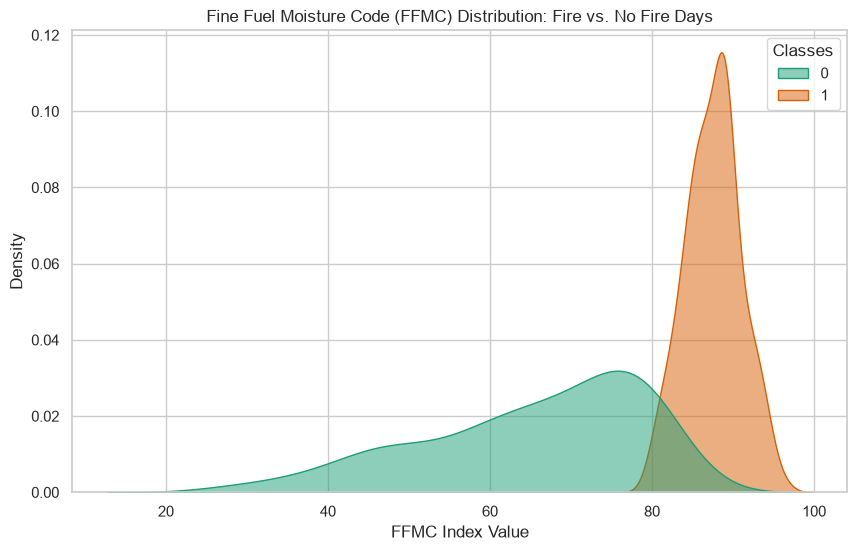

In [6]:
# Visualizing Your Strongest Predictor (FFMC)
plt.figure(figsize=(10, 6))

# Plot distribution of FFMC split by Classes
sns.kdeplot(data=df, x="FFMC", hue="Classes", fill=True, palette="Dark2", common_norm=False, alpha=0.5)

plt.title("Fine Fuel Moisture Code (FFMC) Distribution: Fire vs. No Fire Days")
plt.xlabel("FFMC Index Value")
plt.ylabel("Density")
plt.show()

C:\Users\kshitija\AppData\Local\Temp\ipykernel_14600\2902151780.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 0], data=df, y="Temperature", x="Classes", palette="Set2")
C:\Users\kshitija\AppData\Local\Temp\ipykernel_14600\2902151780.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], data=df, y="RH", x="Classes", palette="Set2")
C:\Users\kshitija\AppData\Local\Temp\ipykernel_14600\2902151780.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 0], data=df, y="Ws", x="Classes", palette="Set2")
C:\Us

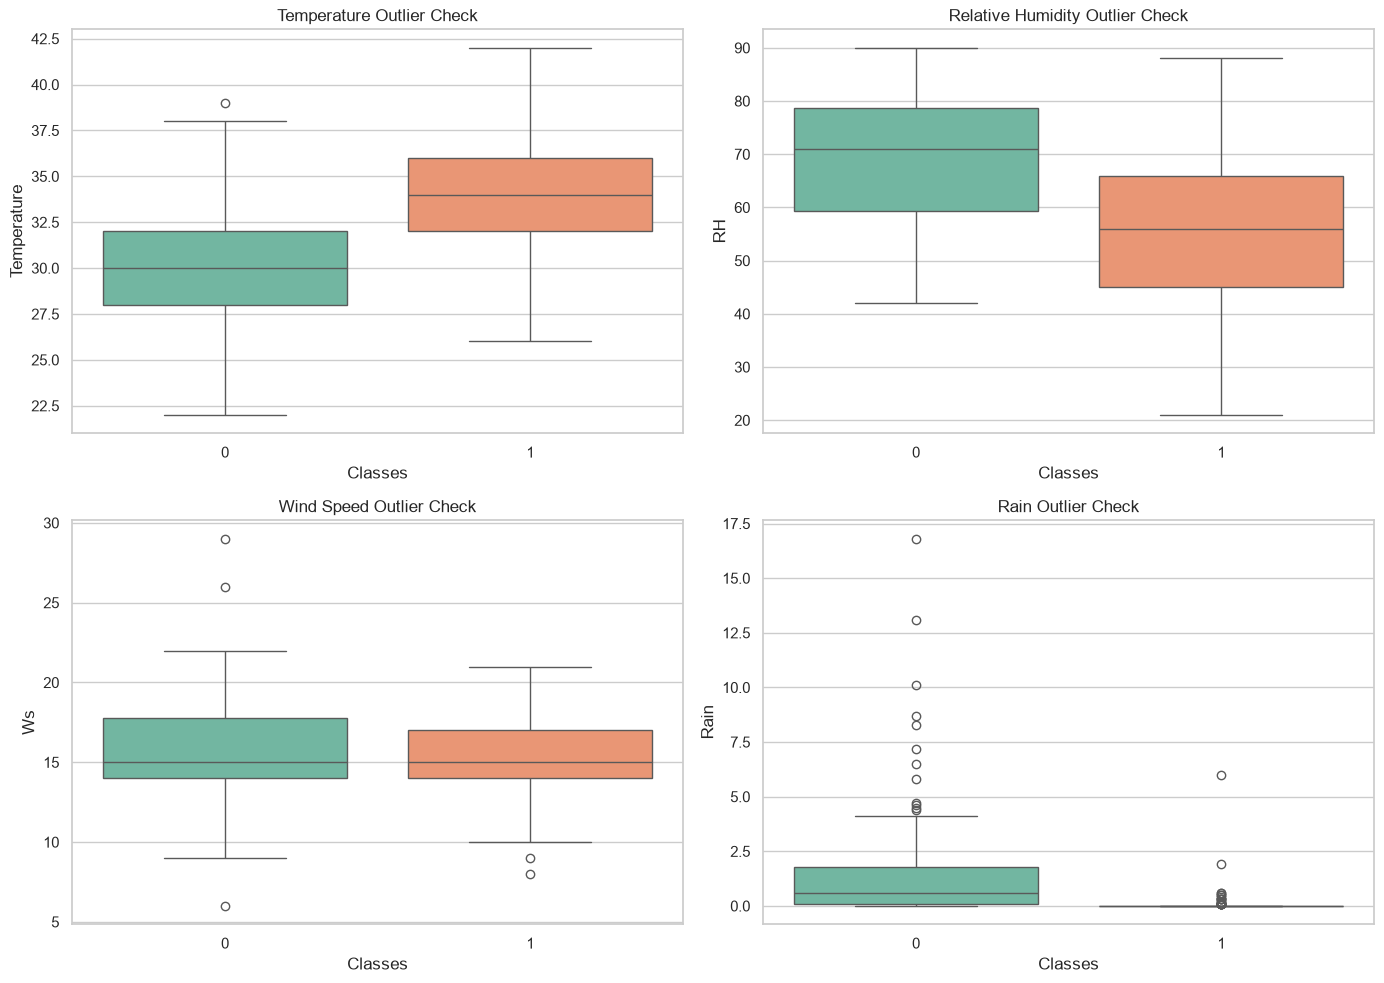

In [7]:
# Let's use a Boxplot Grid to check out the spreads of these 4 primary weather metrics all at once.
# (Temperature, RH, Ws, Rain)

# Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Temperature Boxplot
sns.boxplot(ax=axes[0, 0], data=df, y="Temperature", x="Classes", palette="Set2")
axes[0, 0].set_title("Temperature Outlier Check")

# 2. Relative Humidity Boxplot
sns.boxplot(ax=axes[0, 1], data=df, y="RH", x="Classes", palette="Set2")
axes[0, 1].set_title("Relative Humidity Outlier Check")

# 3. Wind Speed Boxplot
sns.boxplot(ax=axes[1, 0], data=df, y="Ws", x="Classes", palette="Set2")
axes[1, 0].set_title("Wind Speed Outlier Check")

# 4. Rain Boxplot
sns.boxplot(ax=axes[1, 1], data=df, y="Rain", x="Classes", palette="Set2")
axes[1, 1].set_title("Rain Outlier Check")

plt.tight_layout()
plt.show()
